In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Step 1 - Bringing in clean SPY data. Creating a prices dataset with all 3 ETF's. Then, calculating daily returns for SPY.

In [2]:
# Load your 3 WSJ CSV files from data folder
# Replace 'SPY.csv', 'QQQ.csv', 'IWM.csv' with your ACTUAL filenames
spy_data = pd.read_csv('/Users/Sinthu/Desktop/(Quant Trading Project)/data/spy.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')
qqq_data = pd.read_csv('/Users/Sinthu/Desktop/(Quant Trading Project)/data/qqq.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')
iwm_data = pd.read_csv('/Users/Sinthu/Desktop/(Quant Trading Project)/data/iwm.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')

#Clean up column names for each data set (they have unneccasary space at the beginning of the column
spy_data.columns = spy_data.columns.str.strip()
qqq_data.columns = qqq_data.columns.str.strip()
iwm_data.columns = iwm_data.columns.str.strip()

#Making sure dates start with oldest to newest
spy_data.sort_index(inplace=True)
qqq_data.sort_index(inplace=True)
iwm_data.sort_index(inplace=True)

# Show first few rows of each
print("SPY shape:", spy_data.shape)
print("\nSPY:")
spy_data.head()

SPY shape: (8341, 5)

SPY:


,Open,High,Low,Close,Volume
Date,,,,,
1993-01-29,43.8595,43.9688,43.7500,43.9375,1003200
1993-02-01,43.9688,44.2500,43.9688,44.2500,480500
1993-02-02,44.2188,44.3750,44.1250,44.3438,201300
1993-02-03,44.4063,44.8438,44.3750,44.8125,529400
1993-02-04,44.9688,45.0938,44.8750,45.0000,531500


In [3]:
# Extract adjusted close prices and combine
spy = pd.DataFrame({'Adj_Close': spy_data['Close']  })

print("Combined prices shape:", spy.shape)
print("\nFirst 5 rows:")
spy.head()

Combined prices shape: (8341, 1)

First 5 rows:


,Adj_Close
Date,
1993-01-29,43.9375
1993-02-01,44.2500
1993-02-02,44.3438
1993-02-03,44.8125
1993-02-04,45.0000


In [4]:
spy["log_return"] = np.log(spy["Adj_Close"] / spy["Adj_Close"].shift(1))
spy = spy.dropna(subset=["log_return"])
spy.head()

,Adj_Close,log_return
Date,,
1993-02-01,44.2500,0.007087
1993-02-02,44.3438,0.002118
1993-02-03,44.8125,0.010514
1993-02-04,45.0000,0.004175
1993-02-05,44.9688,-0.000694


Step 2 - Resample to monthly data.

In [5]:
# Last available price each month (Month is now ME not M)
spy_monthly_price = spy["Adj_Close"].resample("ME").last()
spy_monthly_price.head()

Date
1993-02-28    44.4063
1993-03-31    45.1875
1993-04-30    44.0313
1993-05-31    45.2188
1993-06-30    45.0625
Freq: ME, Name: Adj_Close, dtype: float64

In [6]:
spy_monthly_return = spy_monthly_price.pct_change().dropna()
spy_monthly_return.head()

Date
1993-03-31    0.017592
1993-04-30   -0.025587
1993-05-31    0.026969
1993-06-30   -0.003457
1993-07-31   -0.004853
Freq: ME, Name: Adj_Close, dtype: float64

In [7]:
print("Daily log return mean:", spy["log_return"].mean())
print("Daily log return std :", spy["log_return"].std())

print("\nMonthly simple return mean:", spy_monthly_return.mean())
print("Monthly simple return std :", spy_monthly_return.std())

Daily log return mean: 0.00032529200922161596
Daily log return std : 0.011735641174216322

Monthly simple return mean: 0.007745423073719495
Monthly simple return std : 0.04259603302703256


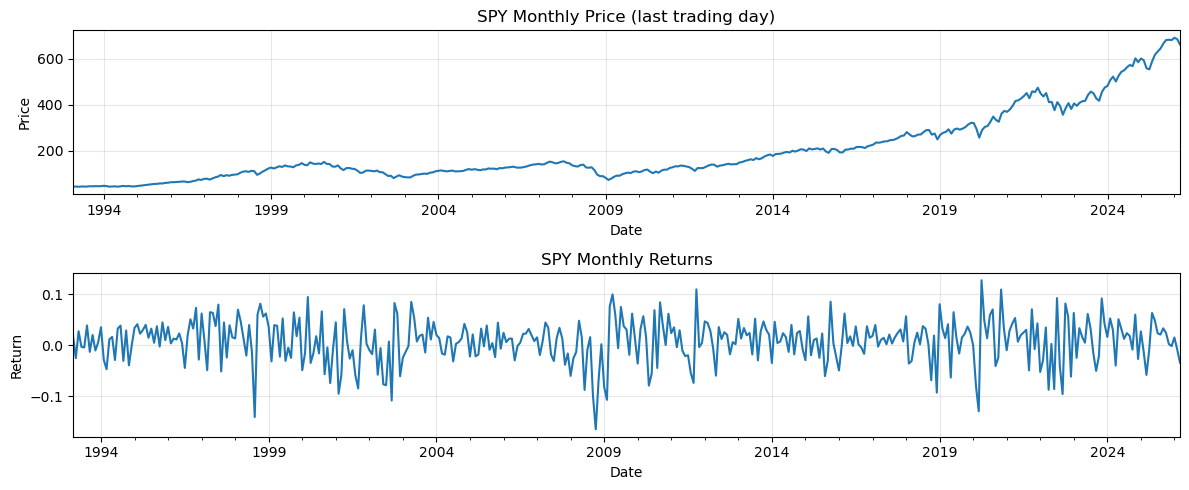

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1)
spy_monthly_price.plot(title="SPY Monthly Price (last trading day)")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
spy_monthly_return.plot(title="SPY Monthly Returns")
plt.ylabel("Return")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Step 3 - Rolling Stats (moving averages and volatility)

In [9]:
spy["ma_20"] = spy["Adj_Close"].rolling(window=20).mean()
spy["ma_50"] = spy["Adj_Close"].rolling(window=50).mean()
spy[["Adj_Close", "ma_20", "ma_50"]].head(25)

,Adj_Close,ma_20,ma_50
Date,,,
1993-02-01,44.2500,NaN,NaN
1993-02-02,44.3438,NaN,NaN
1993-02-03,44.8125,NaN,NaN
1993-02-04,45.0000,NaN,NaN
1993-02-05,44.9688,NaN,NaN
1993-02-08,44.9688,NaN,NaN
1993-02-09,44.6563,NaN,NaN
1993-02-10,44.7188,NaN,NaN
1993-02-11,44.9375,NaN,NaN


In [10]:
# 20-day rolling std of daily log returns
spy["roll_vol_20"] = spy["log_return"].rolling(window=20).std()

# Annualised rolling vol (assuming 252 days)
spy["roll_vol_20_annual"] = spy["roll_vol_20"] * np.sqrt(252)

spy[["log_return", "roll_vol_20", "roll_vol_20_annual"]].dropna().head()

,log_return,roll_vol_20,roll_vol_20_annual
Date,,,
1993-03-01,-0.002819,0.007853,0.124662
1993-03-02,0.014710,0.008364,0.132767
1993-03-03,0.004164,0.008393,0.133240
1993-03-04,-0.005556,0.008189,0.129988
1993-03-05,-0.002789,0.008153,0.129421


Roll vol 20:
- is the daily volatility based on the last 20 days. Small number harder to interept in finance
- how much it moves per day

Roll vol 20 annual:
- is the annual volatility same data as the above just scaled for annual trading days. Easy to interept in (industry standard)
- how risky it is over a year

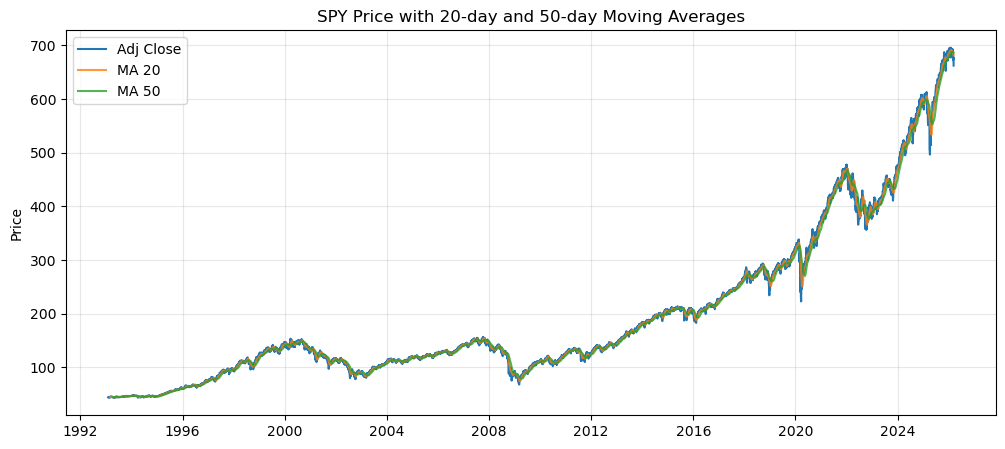

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(spy.index, spy["Adj_Close"], label="Adj Close", linewidth=1.5)
plt.plot(spy.index, spy["ma_20"], label="MA 20", alpha=0.8)
plt.plot(spy.index, spy["ma_50"], label="MA 50", alpha=0.8)
plt.title("SPY Price with 20-day and 50-day Moving Averages")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

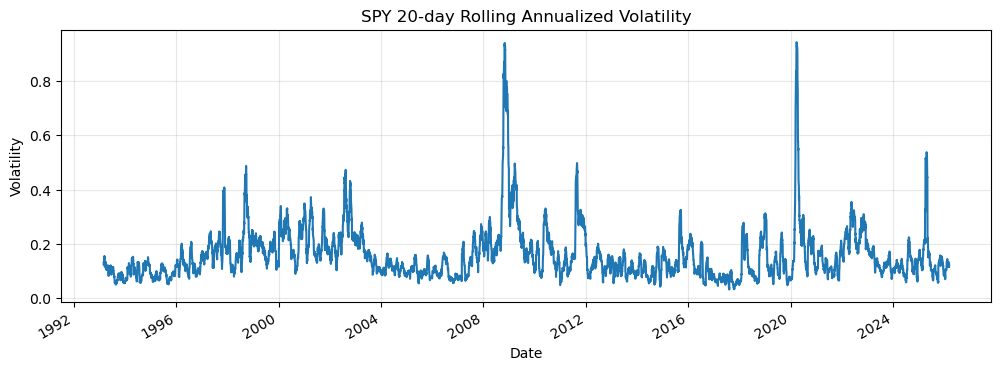

In [12]:
plt.figure(figsize=(12, 4))
spy["roll_vol_20_annual"].plot(title="SPY 20-day Rolling Annualized Volatility")
plt.ylabel("Volatility")
plt.grid(True, alpha=0.3)
plt.show()

Step 4 - Simple resampling to yearly data (Just to see another resample)

Yearly returns:
Date
1994-12-31   -0.022134
1995-12-31    0.349452
1996-12-31    0.201017
1997-12-31    0.314430
1998-12-31    0.270444
1999-12-31    0.191080
2000-12-31   -0.106809
2001-12-31   -0.128728
2002-12-31   -0.228084
2003-12-31    0.261249
2004-12-31    0.086179
2005-12-31    0.030115
2006-12-31    0.137419
2007-12-31    0.032411
2008-12-31   -0.382806
2009-12-31    0.234929
2010-12-31    0.128410
2011-12-31   -0.001988
2012-12-31    0.134741
2013-12-31    0.296889
2014-12-31    0.112892
2015-12-31   -0.008125
2016-12-31    0.096434
2017-12-31    0.193844
2018-12-31   -0.063479
2019-12-31    0.287852
2020-12-31    0.161623
2021-12-31    0.270354
2022-12-31   -0.194816
2023-12-31    0.242868
2024-12-31    0.233048
2025-12-31    0.163527
2026-12-31   -0.028786
Freq: YE-DEC, Name: Adj_Close, dtype: float64


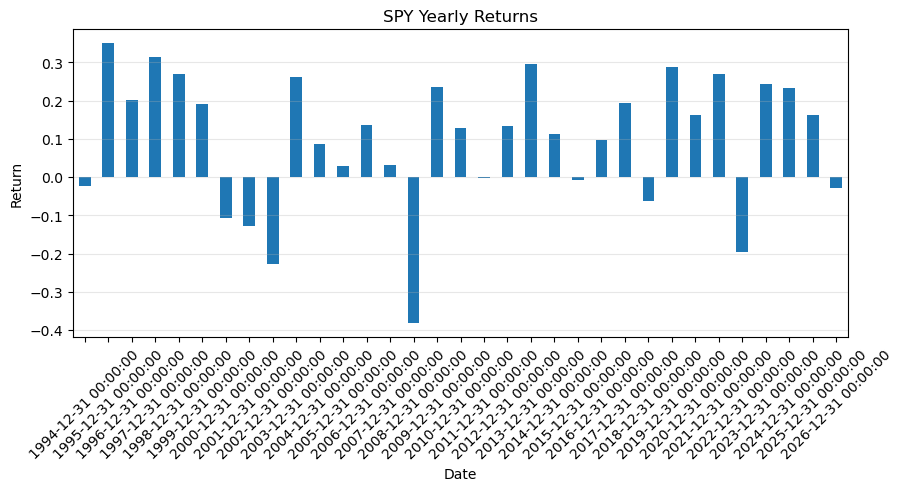

In [13]:
# Year-end price each year (For year it's YE not Y)
spy_yearly_price = spy["Adj_Close"].resample("YE").last()
spy_yearly_return = spy_yearly_price.pct_change().dropna()

print("Yearly returns:")
print(spy_yearly_return)

plt.figure(figsize=(10, 4))
spy_yearly_return.plot(kind="bar", title="SPY Yearly Returns", rot=45)
plt.ylabel("Return")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## Time series basics – reflections (SPY WSJ data)

- What I understand now about resampling (daily → monthly → yearly):
  - Roll vol 20 annualised is the standard way to show returns for volitality
  - Simple process just the initial collection of data

- What I see in the 20-day vs 50-day moving averages:
  - Small vol for 50 day moving vs 20 day vol
  - 20 day vol accurate to the real vol and has a consistent vol

- What the rolling volatility plot tells me about "calm" vs "turbulent" periods:
  - During "turbulent" vol spikes to a high clear in 2008, 2021 and 2024
  - "Calm" periods maintain a vol under a certain value

- Anything that was confusing about resample() or rolling():
  - Initially unsure why when working vol annulaised, used sqrt 252 not 365. Then, found out it's so it can match number of trading days.